In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import joblib
import time
import numpy as np

# Cấu hình hiển thị biểu đồ ngay trong IDE
%matplotlib inline

In [50]:
# Functions
def load_and_clean_data(filepath="ad.data"):
    print("\n[1/6] Loading and cleaning data...")
    try:
        df = pd.read_csv(filepath, header=None, low_memory=False)
    except FileNotFoundError:
        print(f"ERROR: File '{filepath}' not found."); return None
    df.rename(columns={1558: "label"}, inplace=True)
    df = df.replace(to_replace='[?]', value=np.nan, regex=True)
    df.dropna(inplace=True)
    feature_cols = df.columns[:-1]
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric)
    return df

def prepare_data(df):
    df["label"] = df["label"].apply(lambda x: 1 if str(x).strip() == "ad." else 0)
    X = df.drop("label", axis=1).values
    y = df["label"].values
    return train_test_split(X, y)

def train_model(X_train, y_train):
    clf = RandomForestClassifier()
    clf.fit(X_train, y_train)
    return clf

def evaluate_model(clf, X_train, y_train, X_test, y_test):
    score = clf.score(X_test, y_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5)
    return cv_scores, cv_scores.mean()
    
def visualize_results(clf, y_test, y_pred, cv_scores, cv_mean, feature_names=None):
    """
    Hàm trực quan hóa kết quả huấn luyện mô hình NodeShield.
    Cấu trúc: 3 biểu đồ xếp dọc (Vertical Stacking).
    """
    # 1. Cấu hình theme chuyên nghiệp và triệt tiêu Warning
    sns.set_theme(style="whitegrid", palette="muted")
    
    # 2. Tạo khung hình với 3 hàng, 1 cột. Figsize (10, 18) là tỉ lệ vàng cho view dọc.
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))
    fig.suptitle('BÁO CÁO PHÂN TÍCH HIỆU NĂNG MÔ HÌNH NODESHIELD', 
                 fontsize=18, fontweight='bold', y=1.02)

    # --- BIỂU ĐỒ 1: CROSS-VALIDATION (Đã sửa lỗi FutureWarning) ---
    folds = [f"Lần {i+1}" for i in range(len(cv_scores))]
    # Gán x cho hue và legend=False để tuân thủ định dạng mới của Seaborn
    barplot = sns.barplot(x=folds, y=cv_scores, hue=folds, ax=ax1, 
                          palette="Blues_d", edgecolor=".2", legend=False)
    
    ax1.axhline(cv_mean, color='red', linestyle='--', linewidth=2, 
                label=f'Trung bình: {cv_mean * 100:.2f}%')
    
    for p in barplot.patches:
        barplot.annotate(f'{p.get_height()*100:.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 9), 
                        textcoords='offset points', fontsize=11, fontweight='bold')

    ax1.set_title('1. Độ chính xác qua 5 lượt kiểm chứng (Cross-Validation)', fontsize=14, pad=15)
    ax1.set_ylim(0.8, 1.05)
    ax1.legend(loc='lower right')
    ax1.set_ylabel('Accuracy Score')

    # --- BIỂU ĐỒ 2: CONFUSION MATRIX ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
                annot_kws={"size": 15, "weight": "bold"}, cbar=False)

    ax2.set_title('2. Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, pad=15)
    ax2.set_xticklabels(['Sạch (Dự đoán)', 'Ads (Dự đoán)'], fontsize=12)
    ax2.set_yticklabels(['Sạch (Thực tế)', 'Ads (Thực tế)'], fontsize=12)
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_ylabel('Actual Label', fontsize=12)

    # --- BIỂU ĐỒ 3: FEATURE IMPORTANCE (Tích hợp vào Subplot dọc) ---
    importances = clf.feature_importances_
    indices = np.argsort(importances)[-10:] # Lấy top 10 đặc trưng
    
    # Sử dụng feature_names nếu được truyền vào, nếu không dùng chỉ số index
    names = [feature_names[i] if feature_names is not None else f"Feature {i}" for i in indices]
    
    ax3.barh(range(len(indices)), importances[indices], color='teal', align='center', edgecolor='black')
    ax3.set_yticks(range(len(indices)))
    ax3.set_yticklabels(names, fontsize=11)
    ax3.set_title('3. Top 10 Đặc trưng quan trọng nhất (Feature Importance)', fontsize=14, pad=15)
    ax3.set_xlabel('Gini Importance / Information Gain')
    ax3.grid(axis='x', linestyle='--', alpha=0.6)

    # Tối ưu hóa khoảng cách giữa các hàng để không bị chồng lấp tiêu đề
    plt.tight_layout()
    plt.show()

In [51]:
# Step1: Nạp và làm sạch data
df = load_and_clean_data("ad.data")
if df is not None:
    print("Dữ liệu sau khi làm sạch:")
    print(df.head())


[1/6] Loading and cleaning data...
Dữ liệu sau khi làm sạch:
     0    1       2  3  4  5  6  7  8  9  ...  1549  1550  1551  1552  1553  \
0  125  125  1.0000  1  0  0  0  0  0  0  ...     0     0     0     0     0   
1   57  468  8.2105  1  0  0  0  0  0  0  ...     0     0     0     0     0   
2   33  230  6.9696  1  0  0  0  0  0  0  ...     0     0     0     0     0   
3   60  468  7.8000  1  0  0  0  0  0  0  ...     0     0     0     0     0   
4   60  468  7.8000  1  0  0  0  0  0  0  ...     0     0     0     0     0   

   1554  1555  1556  1557  label  
0     0     0     0     0    ad.  
1     0     0     0     0    ad.  
2     0     0     0     0    ad.  
3     0     0     0     0    ad.  
4     0     0     0     0    ad.  

[5 rows x 1559 columns]


In [52]:
# Step 2: Phân tách tập dữ liệu
X_train, X_test, y_train, y_test = prepare_data(df)
print(f"Kích thước Train: {X_train.shape} | Kích thước Test: {X_test.shape}")

Kích thước Train: (1769, 1558) | Kích thước Test: (590, 1558)


In [53]:
# Step3: Huấn luyện model
print("Đang huấn luyện mô hình...")
clf = train_model(X_train, y_train)
print("Mô hình đã được huấn luyện thành công.")

Đang huấn luyện mô hình...
Mô hình đã được huấn luyện thành công.


In [54]:
# Step 4 + 5: Đánh giá và kiểm chứng
cv_scores, cv_mean = evaluate_model(clf, X_train, y_train, X_test, y_test)
y_pred = clf.predict(X_test)

print(f"Độ chính xác trung bình: {cv_mean * 100:.2f}%")
print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_test, y_pred, target_names=["Sạch", "Quảng cáo"]))

Độ chính xác trung bình: 97.51%

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

        Sạch       0.99      1.00      0.99       489
   Quảng cáo       0.99      0.94      0.96       101

    accuracy                           0.99       590
   macro avg       0.99      0.97      0.98       590
weighted avg       0.99      0.99      0.99       590



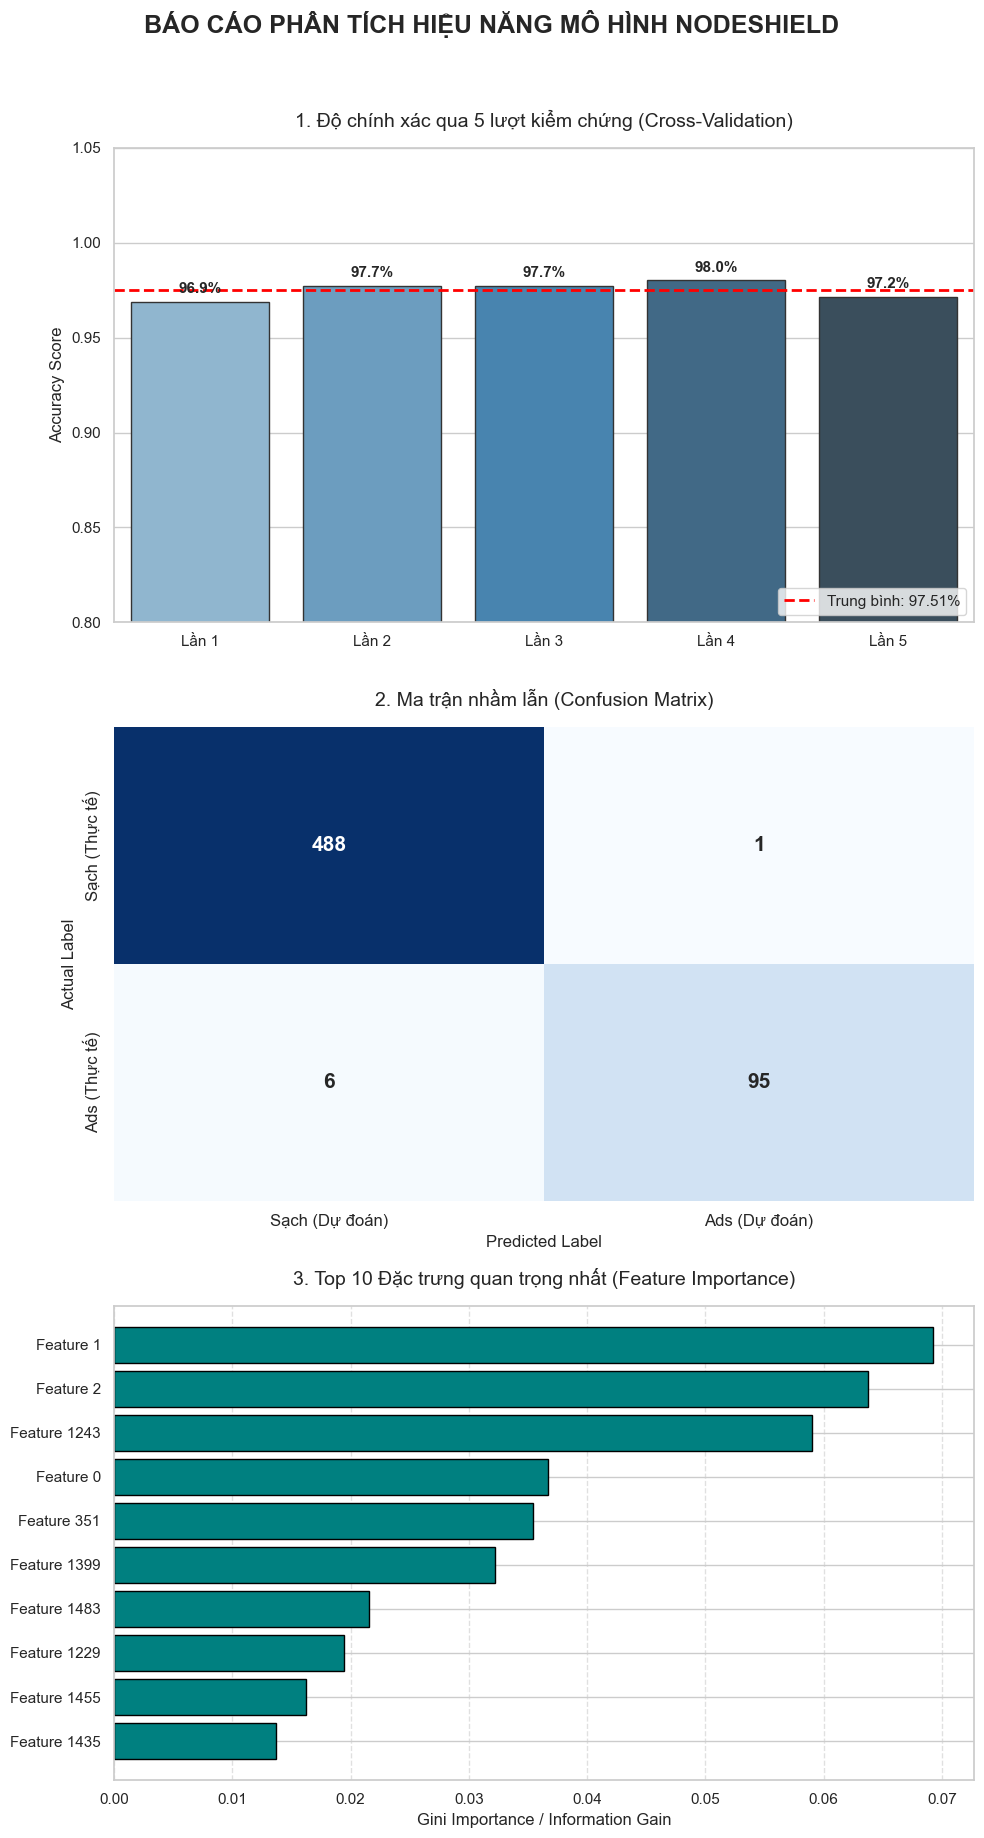

✅ Mô hình đã được lưu tại: original_dataset.joblib


In [55]:
# Trực quan hóa và Lưu trữ
visualize_results(clf, y_test, y_pred, cv_scores, cv_mean)

# Lưu mô hình
joblib.dump(clf, "original_dataset.joblib")
print("✅ Mô hình đã được lưu tại: original_dataset.joblib")